# 04 — Compuerta del maestro (antes de PPO)

No reentrena. No toca test ni holdout. Pregunta única, en **val** p=1,s=1:

**¿El maestro `receding_horizon_ep` empaqueta mejor que el heurístico y que el MLP actual?**

Misma entrada, mismo bucle, mismo validador.

| Veredicto | Siguiente paso |
|-----------|----------------|
| El maestro gana al heurístico (IC emparejado excluye el cero) | Más destilación (más pedidos RH o DAgger). **No** programar PPO todavía |
| Empate o el maestro pierde | Fine-tuning PPO del `mlp_v1_p1s1.pt` |

El maestro es caro (en cada paso empaqueta el resto). Los 8 pedidos de val pueden tardar varios minutos.

Siguiente si el maestro no gana: `05_rl_ppo.ipynb`.

In [1]:
from pathlib import Path
import sys

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    import matplotlib
    matplotlib.use("Agg")

HERE = Path.cwd().resolve()
if HERE.name == "notebooks":
    ML_ROOT = HERE.parent
else:
    ML_ROOT = HERE if (HERE / "src_ml").is_dir() else Path("/home/edmundo/packing-services/online_policy_ml")

REPO_ROOT = ML_ROOT.parent
for p in (ML_ROOT / "src_ml", REPO_ROOT / "src"):
    s = str(p)
    if s not in sys.path:
        sys.path.insert(0, s)

from bootstrap import setup
setup()

import json
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)

print("ML_ROOT =", ML_ROOT)

ML_ROOT = /home/edmundo/packing-services/online_policy_ml


In [2]:
from config import TEACHER_NAME
from paths import (
    BED_JSON_NAME,
    ORDER_IDS_NAME,
    REPORTS_DIR,
    VAL_DIR,
    model_path_mlp,
)
from splits import load_orders
from evaluate import evaluate_orders, write_report
from methodology import (
    GATE_DISTILL,
    GATE_PPO,
    assert_holdout_excluded,
    assert_selection_split,
    interpret_teacher_gate,
)

LOOKAHEAD_P, SELECT_S = 1, 1
mlp_path = model_path_mlp(LOOKAHEAD_P, SELECT_S)
assert mlp_path.is_file(), f"Falta el checkpoint de 03: {mlp_path}"
assert (VAL_DIR / BED_JSON_NAME).is_file(), "Falta el val de 01"

orders_val = load_orders(VAL_DIR / BED_JSON_NAME)
ids_val = json.loads((VAL_DIR / ORDER_IDS_NAME).read_text(encoding="utf-8"))
assert_holdout_excluded(ids_val, role="teacher_gate")
assert_selection_split(ids_val, role="model_selection")

print("maestro", TEACHER_NAME)
print("val n", len(ids_val), ids_val)
print("mlp", mlp_path)

maestro receding_horizon_ep
val n 8 ['00101450', '00101506', '00104020', '00104335', '00105244', '00106072', '00106539', '00109074']
mlp /home/edmundo/packing-services/online_policy_ml/artifacts/models/mlp_v1_p1s1.pt


In [3]:
print("heurístico …", flush=True)
rows_h = evaluate_orders(
    orders_val, ids_val,
    engine="heuristic", lookahead_p=LOOKAHEAD_P, select_s=SELECT_S,
)
print("MLP …", flush=True)
rows_m = evaluate_orders(
    orders_val, ids_val,
    engine="learned", lookahead_p=LOOKAHEAD_P, select_s=SELECT_S,
    model_path=str(mlp_path),
)
print("maestro RH (lento) …", flush=True)
rows_t = evaluate_orders(
    orders_val, ids_val,
    engine="teacher", lookahead_p=LOOKAHEAD_P, select_s=SELECT_S,
    teacher=TEACHER_NAME,
)

rows = rows_h + rows_m + rows_t
df = pd.DataFrame(rows)
summary = (
    df.groupby("engine", as_index=False)
    .agg(n=("order_id", "count"), util=("volume_utilization", "mean"),
         packed=("items_packed", "mean"), valid=("is_valid", "mean"),
         sec=("seconds", "sum"))
)
display(summary.round(4))
display(df[["order_id", "engine", "volume_utilization", "items_packed", "is_valid", "seconds"]].round(4))

heurístico …
MLP …
maestro RH (lento) …


,engine,n,util,packed,valid,sec
0,heuristic,8,0.6826,44.750,1.0,16.4225
1,learned,8,0.6865,44.625,1.0,19.9729
2,teacher,8,0.6784,44.500,1.0,192.2832


,order_id,engine,volume_utilization,items_packed,is_valid,seconds
0,00101450,heuristic,0.6795,28,True,0.3971
1,00101506,heuristic,0.7055,36,True,0.5977
2,00104020,heuristic,0.6633,52,True,2.1480
3,00104335,heuristic,0.7094,59,True,3.4634
4,00105244,heuristic,0.6749,20,True,0.1960
5,00106072,heuristic,0.6696,52,True,3.1474
6,00106539,heuristic,0.6910,52,True,2.9007
7,00109074,heuristic,0.6675,59,True,3.5722
8,00101450,learned,0.6874,29,True,3.8260
9,00101506,learned,0.6958,36,True,0.6692


teacher vs heuristic: diferencia -0.0042 (IC95 -0.0191 a +0.0103, n=8) — NO significativa.
teacher vs mlp: diferencia -0.0081 (IC95 -0.0172 a +0.0014, n=8) — NO significativa.

DECISIÓN: ppo
Fine-tuning PPO del mlp_v1_p1s1.pt: el maestro no supera al heurístico; imitar más no tiene techo que perseguir.


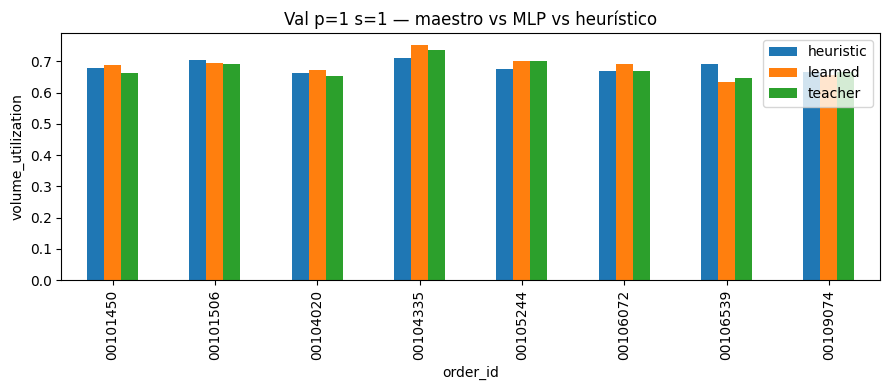

escrito /home/edmundo/packing-services/online_policy_ml/artifacts/reports/04_compuerta_maestro.json


In [4]:
gate = interpret_teacher_gate(rows_t, rows_h, rows_m)
print(gate["verdict_heuristic"])
print(gate["verdict_mlp"])
print()
print("DECISIÓN:", gate["decision"])
print(gate["next_step"])

pivot = df.pivot(index="order_id", columns="engine", values="volume_utilization")
ax = pivot.plot(kind="bar", figsize=(9, 4))
ax.set_ylabel("volume_utilization")
ax.set_title("Val p=1 s=1 — maestro vs MLP vs heurístico")
ax.legend(title=None)
plt.tight_layout()
plt.show()

report = {
    "split": "val",
    "lookahead_p": LOOKAHEAD_P,
    "select_s": SELECT_S,
    "teacher": TEACHER_NAME,
    "mlp_path": str(mlp_path),
    "order_ids": ids_val,
    "rows": rows,
    "gate": gate,
}
out = REPORTS_DIR / "04_compuerta_maestro.json"
write_report(out, report)
print("escrito", out)

assert all(r["is_valid"] for r in rows), "alguna solución no es válida"
assert gate["decision"] in {GATE_DISTILL, GATE_PPO}